# Intro to Retrieval Aumented Generation (RAG)

A technique in AI where a large language model accesses new or recent data outside its training set to provide better answers and improved results.

### **RAG vs Fine-Tuning:**
| Característica / Proceso | RAG (Retrieval-Augmented Generation) | Fine-Tuning (Ajuste Fino) |
| :--- | :--- | :--- |
| **Naturaleza de la técnica** | Arquitectura de software ejecutada en tiempo de inferencia. | Proceso de entrenamiento de Machine Learning. |
| **Modificación del modelo** | El LLM permanece estático ("congelado"); sus pesos internos no cambian. | Los pesos neuronales y parámetros se modifican matemáticamente (mediante técnicas de optimización como PEFT y LoRA). |
| **Flujo de Implementación** | 1. Dividir documentos crudos en *chunks*.<br>2. Convertir los *chunks* a vectores usando modelos de *embeddings*.<br>3. Almacenar los vectores en una Base de Datos Vectorial.<br>4. Al recibir una consulta, buscar el contexto más relevante matemáticamente (ej. similitud coseno).<br>5. Inyectar este contexto junto a la consulta en el *prompt* original. | 1. Curar y estructurar un dataset masivo (usualmente en JSONL con pares *prompt-completion*).<br>2. Provisionar poder de cómputo intensivo (GPUs en la nube como AWS o GCP).<br>3. Entrenar el modelo base iterativamente (*epochs*) para que asimile los patrones.<br>4. Desplegar el modelo resultante en un servidor propio. |
| **Costos y Hardware** | Costo computacional bajo. Solo pagas almacenamiento vectorial y uso estándar de tokens de inferencia. | Costo computacional alto. El entrenamiento inicial es muy costoso y alojar un modelo especializado requiere infraestructura robusta. |
| **Manejo de Información** | Excelente para conocimiento privado o altamente dinámico. Actualizar un dato toma segundos (solo actualizas la base de datos). | Pésimo para almacenar hechos. Si un dato cambia en el mundo real, necesitas volver a gastar en reentrenar el modelo. |
| **Caso de Uso Principal** | Recuperación de información exacta, buscadores semánticos empresariales y reducción estricta de alucinaciones. | Alterar permanentemente el formato sintáctico (ej. responder siempre en JSON válido), el tono, o especializar al modelo en una jerga muy técnica. |


### Implementation

```Python

df = df[df['variety'].notna()]  # before we have to clean our data and drop empty values to avoid troube during serialization
data = df.to_dict('records')    #important to use records, if not, dict will take the data indexes



# ***************** EMBEDDING AND SEARCH *****************

encoder= SentenceTransformer('all-MiniLM-L6-v2') # model to create embbedings

qdrant = QdrantClient(':memory:')   # create in-memory Qdrant instance

# create collection to store books -> data vectors?
qdrant.recrete_collection(
    collection_name = 'top_wines',
    vectors_config = model.VectorParams(
        size = encoder.get_setence_embedding_dimension(),   #vector size is defined by used model
        distance = models.Distance.COSINE
    )

)

# vectorize !
qdrant.upload_points(
    collection_name = 'top_wines',
    points = [
        models.PointStruct(
            id = idx,
            vector = encoder.encode(doc['notes']).tolist(), # pass nodes as vectors
            paylod = doc
        ) for idx, doc in enumerate(data)
    ]


)


user_prompt = 'a wine from mendoz argentina'  # query example, we can change this text!!


# search time 
hits = qdrant.search(
    collection_name = 'top_wines',
    query_vector = encoder.encode(user_prompt).tolist(),
    limit = 3
)
for hit in hits:
    print(hit.payload, 'score:', hit.score)


# ******************* USING RAG WITH LLM *******************
```
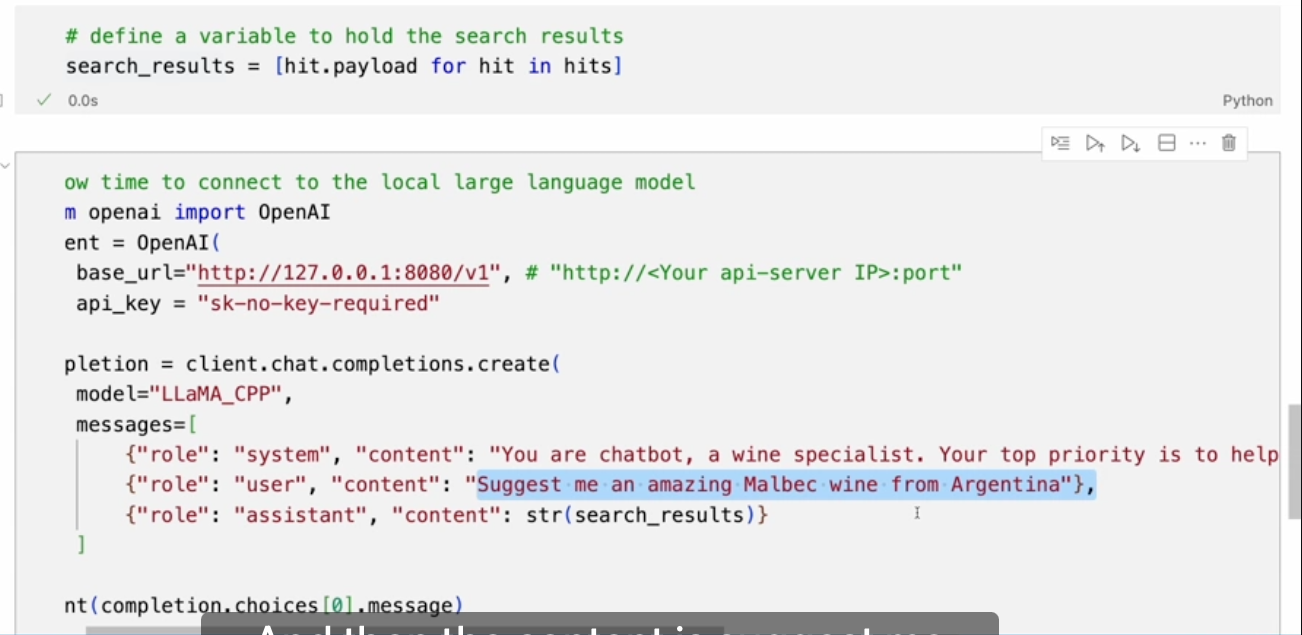
